# EDA of credit card data

Let's start by importing the necessary libraries. For this eda we will import numpy, pandas, matplotlb and seaborn.

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Now lets work on importing the data from the excel file using pandas. we will store this data in a pandas Data Frame. We will also see 5 random data points of this dataset.

In [127]:
data = pd.read_excel("default of credit card clients.xls", header = 1)
data.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
3727,3728,120000,2,2,2,24,-1,-1,-1,-1,...,902,1077,1271,1742,1077,902,1077,1271,1595,0
10402,10403,10000,2,2,1,26,1,2,2,2,...,5951,6255,6401,0,1500,0,400,400,700,1
22909,22910,200000,2,2,1,37,0,0,0,0,...,124327,127011,134519,5000,7000,4500,4500,9500,5000,0
25871,25872,80000,2,2,1,36,1,-2,-2,-2,...,10000,10000,10000,14233,15854,10000,10000,10000,10000,0
7024,7025,200000,2,2,2,25,0,0,0,0,...,29962,30733,39192,2569,4500,1800,2000,9000,5000,0


As you can see the data columns aren't clear. We will name them properly before doing anything else.

This is much more better. now as Id columns is useless, lets drop it.

In [128]:
data = data.drop(columns = 'ID')
data.sample(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
24563,250000,1,2,2,44,0,0,0,0,0,...,153130,153859,103593,8000,6018,6887,6000,4001,12000,0
26213,430000,2,1,2,34,-1,-1,-1,2,-1,...,7370,4423,2544,1662,15783,52,4445,2556,3321,0
19519,80000,2,2,1,26,0,0,0,0,-2,...,0,0,0,4000,4000,0,0,0,0,1
12331,310000,2,1,2,36,1,-1,-1,-1,-1,...,1624,0,0,1711,0,1632,0,0,173,0
10983,50000,2,1,1,35,0,0,0,-2,-2,...,0,0,0,2400,0,0,0,0,0,0


In [129]:
data.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Now let's understand the meaning of the features. After researching, I found that :
- LIMIT_BAL: Amount of the given credit (in NT dollars).
- SEX: Gender (1 = male; 2 = female).
- EDUCATION: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others; 0, 5, 6 are often grouped into "others/unknown").
- MARRIAGE: Marital status (1 = married; 2 = single; 3 = others).
- AGE: Age in years.
- PAY_0 (or PAY_1), PAY_2, PAY_3, PAY_4, PAY_5, PAY_6: Repayment status for each of the last six months. The values indicate the payment delay:
  - -1 = Pay duly/on time.
  - 0 = No delay.
  - 1 = Payment delay for one month.
  - 2 = Payment delay for two months, etc., up to 9 (nine months and above delay).
- BILL_AMT1 to BILL_AMT6: Amount of bill statement for each of the last six months.
- PAY_AMT1 to PAY_AMT6: Amount of previous payment for each of the last six months.

Now as we know what every feature is, we can explore the data more properly.
Before exploring any feature, lets see if there are any missing values.

In [130]:
data.isna().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

There seems to be no missing data!

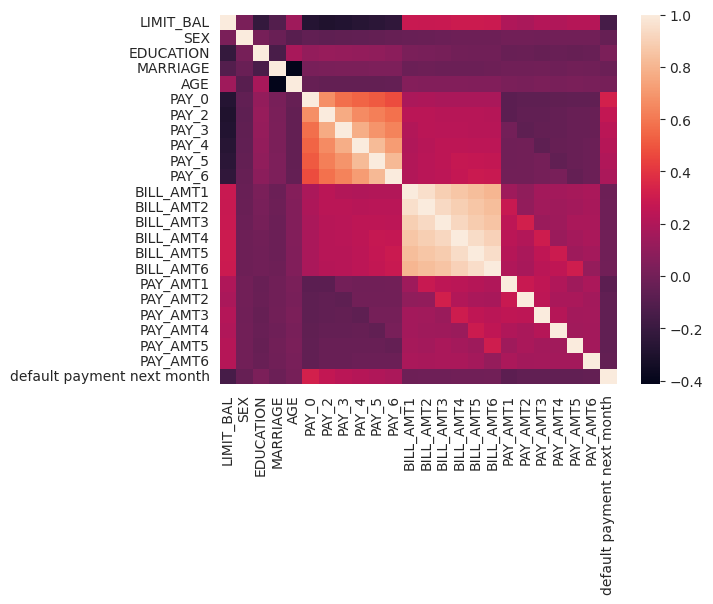

In [131]:
sns.heatmap(data.corr())
plt.show()

In [132]:
print(data.skew(axis = 0))

LIMIT_BAL                      0.992867
SEX                           -0.424183
EDUCATION                      0.970972
MARRIAGE                      -0.018742
AGE                            0.732246
PAY_0                          0.731975
PAY_2                          0.790565
PAY_3                          0.840682
PAY_4                          0.999629
PAY_5                          1.008197
PAY_6                          0.948029
BILL_AMT1                      2.663861
BILL_AMT2                      2.705221
BILL_AMT3                      3.087830
BILL_AMT4                      2.821965
BILL_AMT5                      2.876380
BILL_AMT6                      2.846645
PAY_AMT1                      14.668364
PAY_AMT2                      30.453817
PAY_AMT3                      17.216635
PAY_AMT4                      12.904985
PAY_AMT5                      11.127417
PAY_AMT6                      10.640727
default payment next month     1.343504
dtype: float64


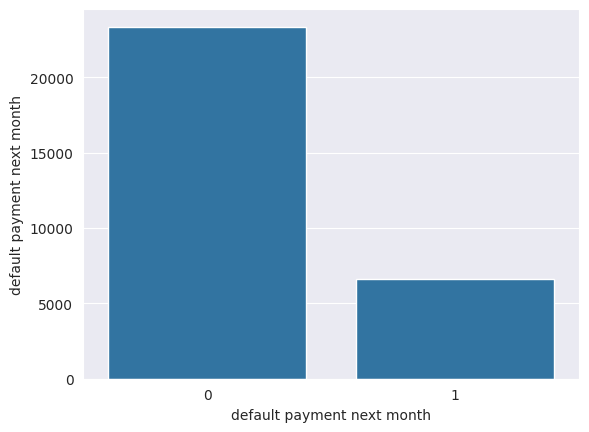

In [133]:
sns.barplot(x = 'default payment next month', y = 'default payment next month',  data = data, estimator = len)
plt.show()

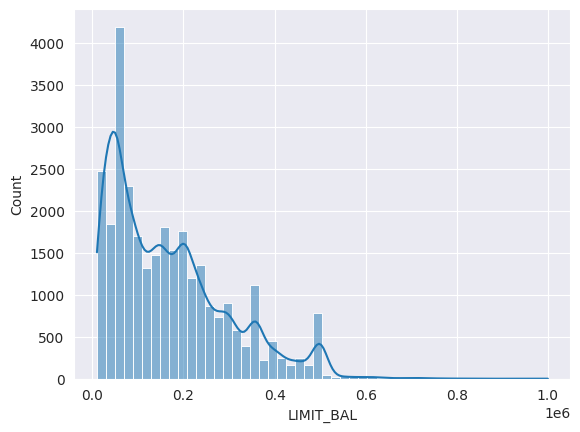

In [134]:
sns.histplot(x = 'LIMIT_BAL', data = data, kde = True, bins = 50)
plt.show()

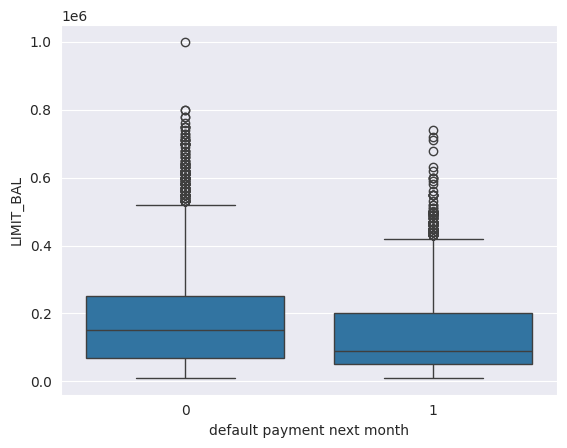

In [135]:
sns.boxplot(y = 'LIMIT_BAL',x = 'default payment next month', data = data)
plt.show()

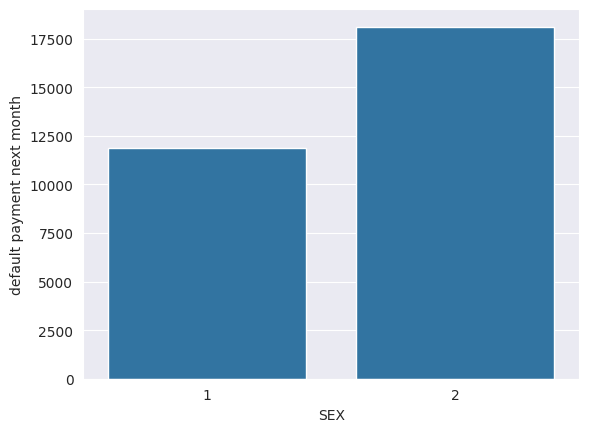

In [136]:
sns.barplot(x = "SEX", y = "default payment next month", data = data, estimator = len)
plt.show()

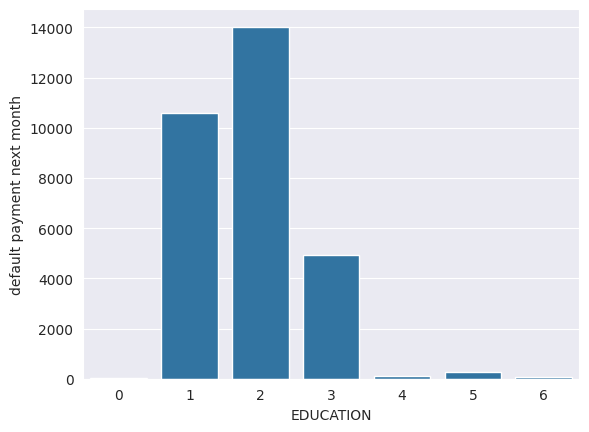

In [137]:
sns.barplot(x = "EDUCATION", y = "default payment next month", data = data, estimator = len)
plt.show()

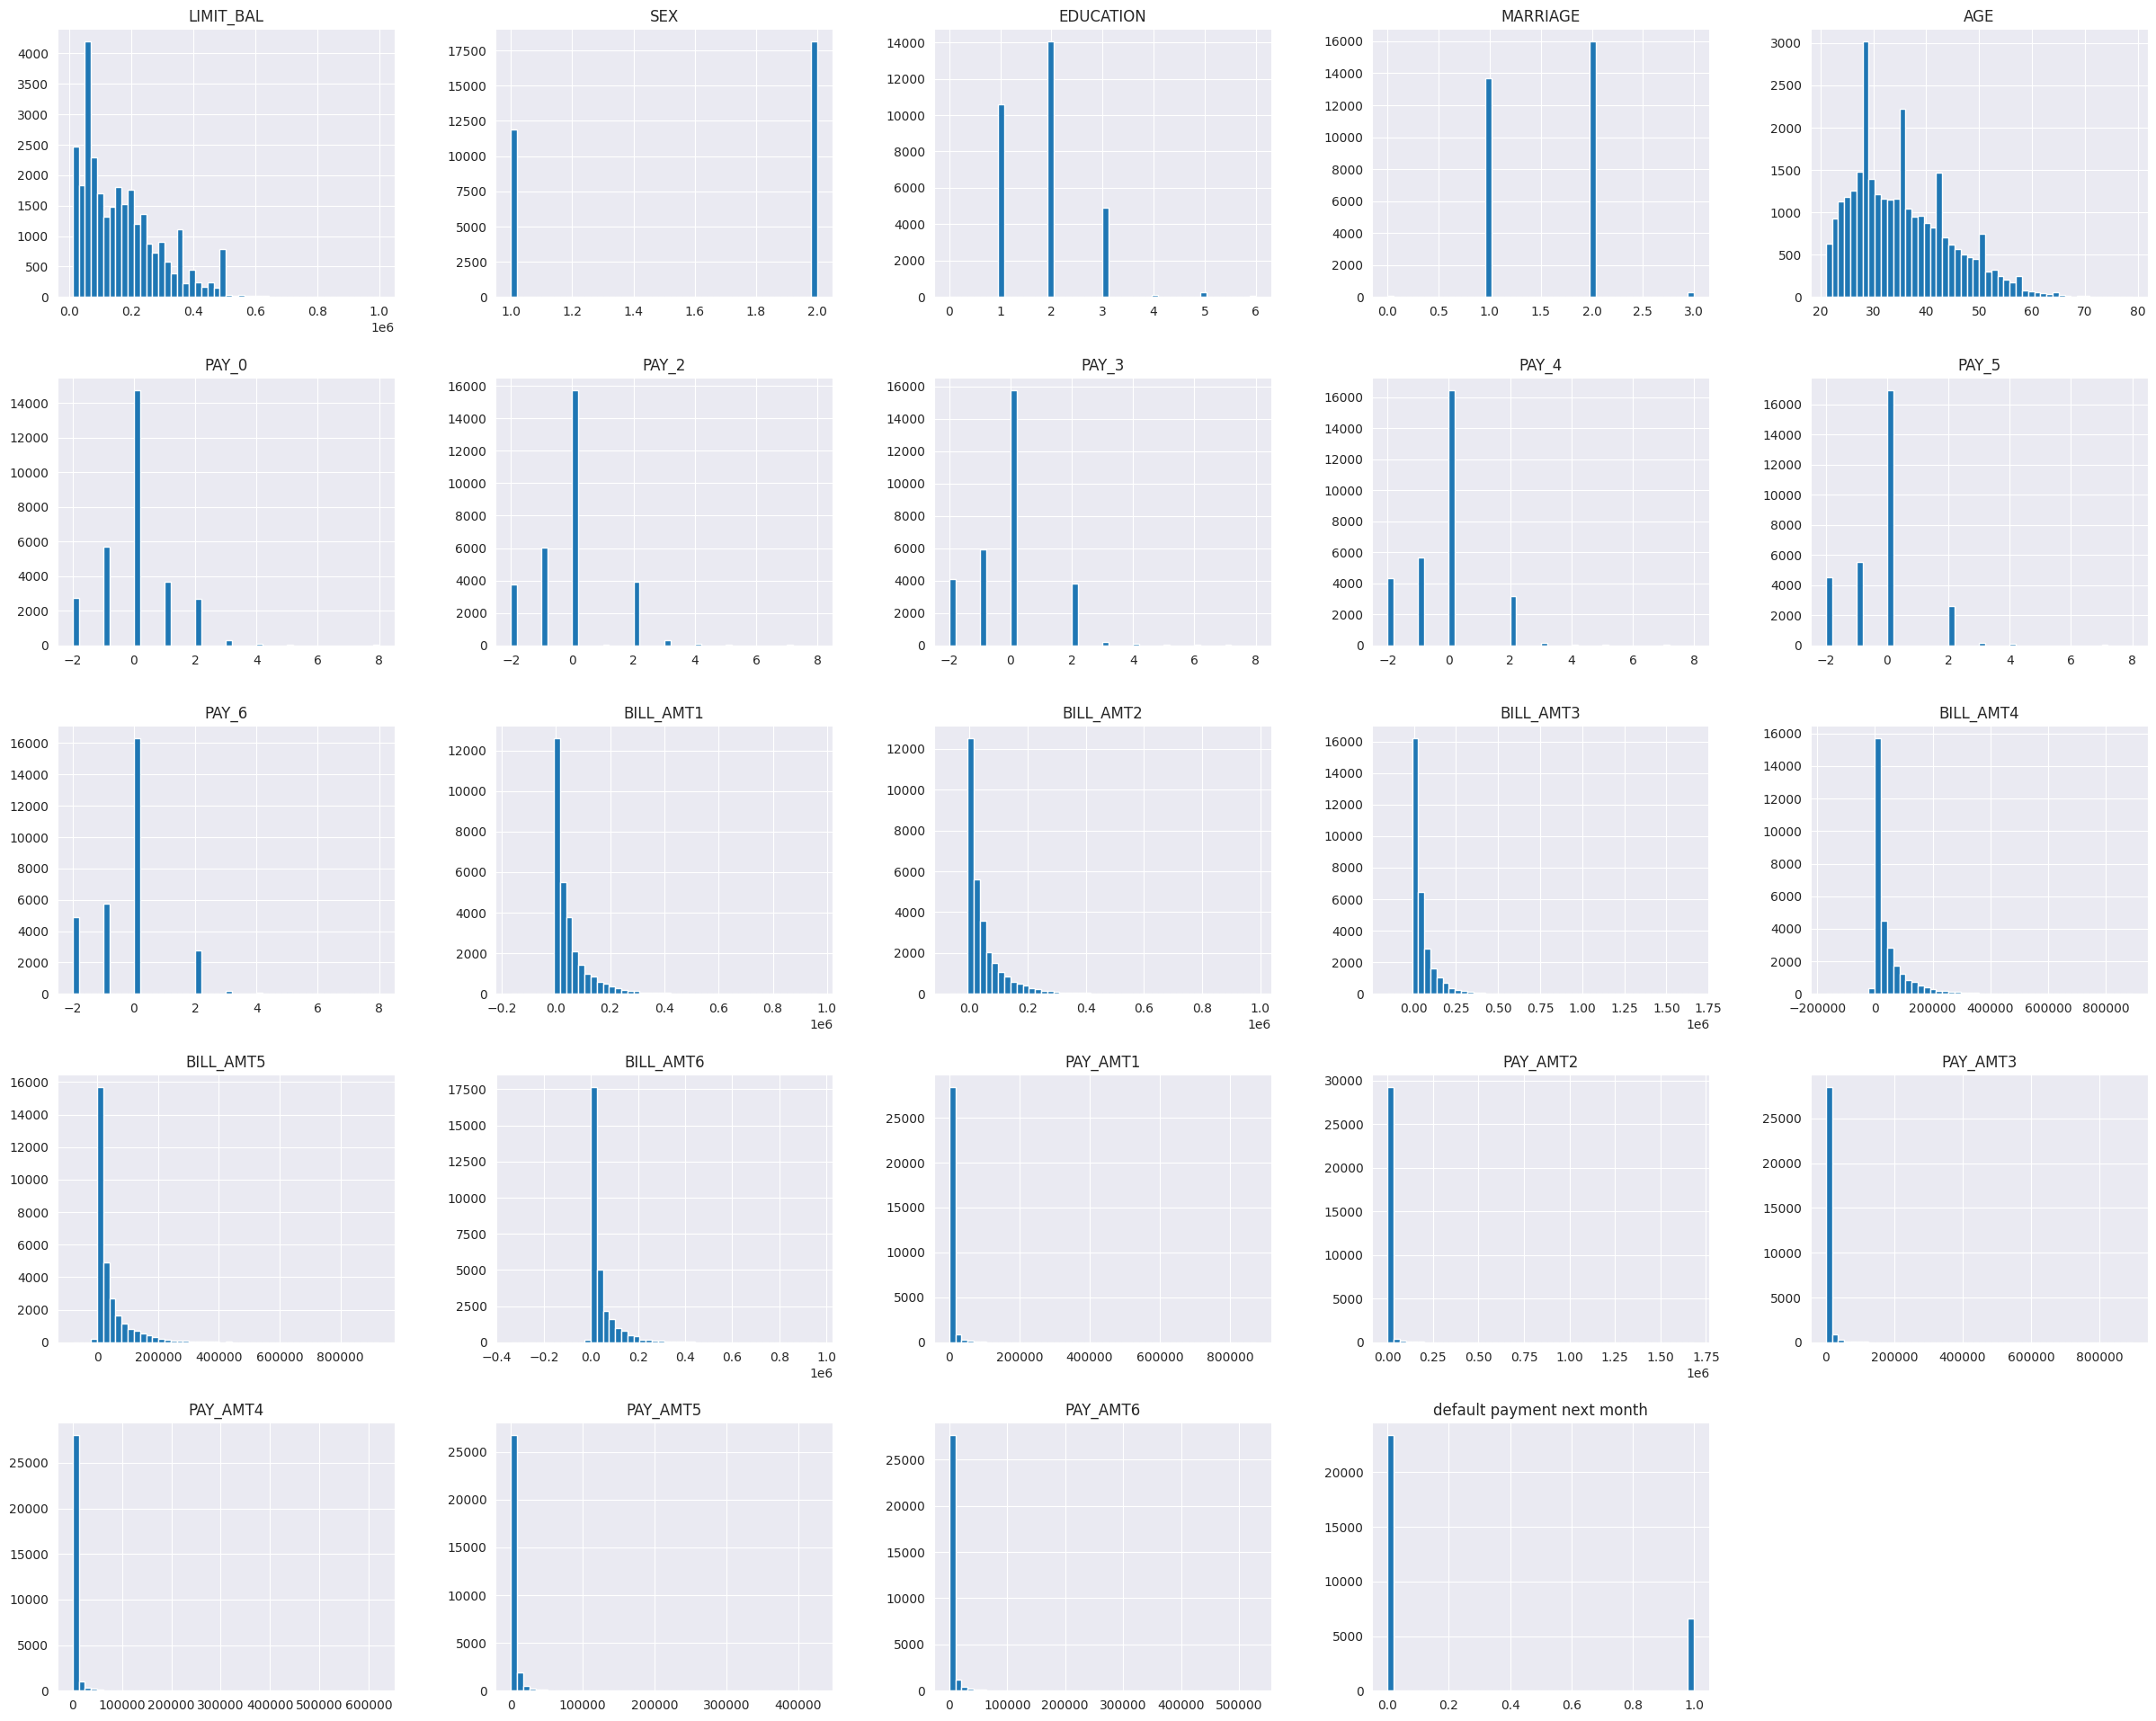

In [138]:
data.hist(figsize=(30, 24), bins=50,layout=(5,5))
plt.show()

In [139]:
data["EDUCATION"].value_counts()/len(data["EDUCATION"])

EDUCATION
2    0.467667
1    0.352833
3    0.163900
5    0.009333
4    0.004100
6    0.001700
0    0.000467
Name: count, dtype: float64

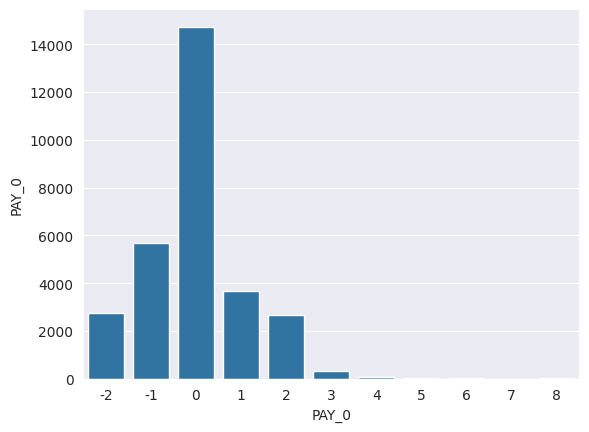

In [140]:
sns.barplot(x = 'PAY_0', y = 'PAY_0',  data = data, estimator = len)
plt.show()

In [141]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import yeojohnson
import numpy as np

to_transform = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6","PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6","LIMIT_BAL","AGE"]

class MinMaxAndYeoJohnson(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lambdas = {}
        self.scalers = {}
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        X = X.copy()
        self.feature_names_in_ = X.columns
        for col in to_transform:
            data = np.asarray(X[col], dtype=float)
            transformed, lmbda = yeojohnson(data)
            self.lambdas[col] = lmbda
            scaler = MinMaxScaler()
            scaler.fit(transformed.reshape(-1, 1))
            self.scalers[col] = scaler
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col in to_transform:
            data = np.asarray(X[col], dtype=float)
            x_yeo = yeojohnson(data, lmbda=self.lambdas[col])
            X[col] = self.scalers[col].transform(x_yeo.reshape(-1, 1)).flatten()
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_, dtype=object)

In [142]:
TOTAL_DATA_POINTS = 30000
TRAIN_RATIO = 0.7
TEST_RATIO = 0.15
VAL_RATIO = 0.15
TRAIN_POINTS = int(TOTAL_DATA_POINTS * TRAIN_RATIO)
VAL_POINTS = int(TOTAL_DATA_POINTS * VAL_RATIO)
TEST_POINTS = int(TOTAL_DATA_POINTS * TEST_RATIO)

In [143]:
train = data[:TRAIN_POINTS]
test = data[TRAIN_POINTS:TRAIN_POINTS+TEST_POINTS]
val = data[TRAIN_POINTS+TEST_POINTS:]

X_train = train.drop(columns="default payment next month")
y_train = train["default payment next month"]

X_test = test.drop(columns="default payment next month")
y_test = test["default payment next month"]

X_val = val.drop(columns="default payment next month")
y_val = val["default payment next month"]

In [144]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

pipeline_logistic = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',LogisticRegression(max_iter=1000))
])

pipeline_catboost = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',CatBoostClassifier())
])

pipeline_xgboost = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',XGBClassifier())
])

In [145]:
pipeline_logistic.fit(X_train, y_train)
y_pred_val_logistic = pipeline_logistic.predict(X_val)

pipeline_catboost.fit(X_train, y_train)
y_pred_val_catboost = pipeline_catboost.predict(X_val)

pipeline_xgboost.fit(X_train, y_train)
y_pred_val_xgboost = pipeline_xgboost.predict(X_val)

Learning rate set to 0.045497
0:	learn: 0.6818923	total: 31.7ms	remaining: 31.7s
1:	learn: 0.6719119	total: 38ms	remaining: 19s
2:	learn: 0.6626885	total: 43.7ms	remaining: 14.5s
3:	learn: 0.6544857	total: 52.3ms	remaining: 13s
4:	learn: 0.6473875	total: 56.8ms	remaining: 11.3s
5:	learn: 0.6407615	total: 61.7ms	remaining: 10.2s
6:	learn: 0.6345025	total: 66.4ms	remaining: 9.43s
7:	learn: 0.6289909	total: 71ms	remaining: 8.8s
8:	learn: 0.6239682	total: 76.4ms	remaining: 8.41s
9:	learn: 0.6194392	total: 81.9ms	remaining: 8.1s
10:	learn: 0.6154266	total: 87ms	remaining: 7.83s
11:	learn: 0.6113403	total: 92.1ms	remaining: 7.58s
12:	learn: 0.6075840	total: 97ms	remaining: 7.36s
13:	learn: 0.6039065	total: 102ms	remaining: 7.17s
14:	learn: 0.6007936	total: 106ms	remaining: 6.97s
15:	learn: 0.5982496	total: 110ms	remaining: 6.79s
16:	learn: 0.5957149	total: 116ms	remaining: 6.68s
17:	learn: 0.5932382	total: 120ms	remaining: 6.55s
18:	learn: 0.5909083	total: 125ms	remaining: 6.45s
19:	learn: 0

In [146]:

from sklearn.model_selection import StratifiedKFold, cross_validate

pipelines = [pipeline_logistic, pipeline_catboost, pipeline_xgboost]
names = ["Pipeline 1", "Pipeline 2", "Pipeline 3"]

# Use StratifiedKFold for classification
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

for name, pipe in zip(names, pipelines):
    results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {results['test_accuracy'].mean():.4f}")
    print(f"Precision: {results['test_precision'].mean():.4f}")
    print(f"Recall:    {results['test_recall'].mean():.4f}")
    print(f"F1-score:  {results['test_f1'].mean():.4f}")


=== Pipeline 1 ===
Accuracy:  0.7238
Precision: 0.6509
Recall:    0.6907
F1-score:  0.6589
Learning rate set to 0.041363
0:	learn: 0.6826829	total: 14.2ms	remaining: 14.2s
1:	learn: 0.6731468	total: 20.6ms	remaining: 10.3s
2:	learn: 0.6645942	total: 26.9ms	remaining: 8.94s
3:	learn: 0.6569977	total: 33.2ms	remaining: 8.26s
4:	learn: 0.6501541	total: 39.3ms	remaining: 7.82s
5:	learn: 0.6437556	total: 47.5ms	remaining: 7.87s
6:	learn: 0.6373488	total: 55.7ms	remaining: 7.9s
7:	learn: 0.6321963	total: 60.5ms	remaining: 7.5s
8:	learn: 0.6269412	total: 65.7ms	remaining: 7.23s
9:	learn: 0.6225113	total: 71.6ms	remaining: 7.09s
10:	learn: 0.6185517	total: 79ms	remaining: 7.11s
11:	learn: 0.6144057	total: 85.1ms	remaining: 7.01s
12:	learn: 0.6108213	total: 90.8ms	remaining: 6.89s
13:	learn: 0.6070550	total: 97.2ms	remaining: 6.85s
14:	learn: 0.6038794	total: 104ms	remaining: 6.83s
15:	learn: 0.6012691	total: 112ms	remaining: 6.87s
16:	learn: 0.5983850	total: 119ms	remaining: 6.86s
17:	learn: 

In [147]:
from sklearn.metrics import recall_score, f1_score, accuracy_score, precision_score

recall_total = recall_score(y_val, y_pred_val_catboost, average = None, labels = [0,1])
f1_total = f1_score(y_val, y_pred_val_catboost, average = None, labels = [0,1])
accuracy_total = accuracy_score(y_val, y_pred_val_catboost)
precision_total = precision_score(y_val, y_pred_val_catboost, average = None, labels = [0,1])

print("CatBoost:")
print("Overall recall:", recall_total)
print("Overall F1-score:", f1_total)
print("Overall accuracy:", accuracy_total)
print("Overall precision:", precision_total)


CatBoost:
Overall recall: [0.84283296 0.59414226]
Overall F1-score: [0.86341957 0.5458914 ]
Overall accuracy: 0.79
Overall precision: [0.88503704 0.50488889]


In [148]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier

pipeline_decision_tree = pipeline_logistic = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',DecisionTreeClassifier(max_depth=1))
])

pipeline_decision_tree.fit(X_train, y_train)
y_pred_val_decision_tree = pipeline_decision_tree.predict(X_val)

recall_total = recall_score(y_val, y_pred_val_decision_tree,  )
f1_total = f1_score(y_val, y_pred_val_decision_tree,  )
accuracy_total = accuracy_score(y_val, y_pred_val_decision_tree)
precision_total = precision_score(y_val, y_pred_val_decision_tree, )

print("Stump:")
print("Overall recall:", recall_total)
print("Overall F1-score:", f1_total)
print("Overall accuracy:", accuracy_total)
print("Overall precision:", precision_total)

Stump:
Overall recall: 0.5104602510460251
Overall F1-score: 0.5072765072765073
Overall accuracy: 0.7893333333333333
Overall precision: 0.5041322314049587


In [149]:
dt = pipeline_decision_tree.named_steps['model']
pre = pipeline_decision_tree.named_steps['yeo_johnson_and_min_max']

# Get feature names after preprocessing
feature_names = pre.get_feature_names_out()
from sklearn.tree import export_text

dt = pipeline_decision_tree.named_steps['model']
tree_rules = export_text(dt, feature_names=feature_names)

print(tree_rules)

|--- PAY_0 <= 0.50
|   |--- class: 0
|--- PAY_0 >  0.50
|   |--- class: 1



In [150]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import recall_score

def objective(trial):

    params = {

        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "Logloss",
        "eval_metric": "Accuracy",
        "random_seed": 42,
        "verbose": 0
    }

    model = Pipeline([
    ('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy='minority')),
    ('model',CatBoostClassifier(iterations = 2000, depth = 3,**params))
])

    model.fit(
        X_train, y_train,
    )

    preds = model.predict(X_val)
    return recall_score(y_val, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2025-11-25 19:14:19,046] A new study created in memory with name: no-name-1cb833b9-b94b-4822-99e3-7c6204183139
[I 2025-11-25 19:14:34,445] Trial 0 finished with value: 0.5930962343096234 and parameters: {'learning_rate': 0.11924671306750853, 'l2_leaf_reg': 0.07628075595057686, 'border_count': 139}. Best is trial 0 with value: 0.5930962343096234.
[I 2025-11-25 19:14:42,846] Trial 1 finished with value: 0.6161087866108786 and parameters: {'learning_rate': 0.018435486928366798, 'l2_leaf_reg': 2.065200717152041, 'border_count': 34}. Best is trial 1 with value: 0.6161087866108786.
[I 2025-11-25 19:14:59,579] Trial 2 finished with value: 0.6119246861924686 and parameters: {'learning_rate': 0.026831376046057284, 'l2_leaf_reg': 9.200522680663644, 'border_count': 46}. Best is trial 1 with value: 0.6161087866108786.
[I 2025-11-25 19:15:16,864] Trial 3 finished with value: 0.6223849372384938 and parameters: {'learning_rate': 0.017814661749112223, 'l2_leaf_reg': 1.1125714546728647, 'border_coun

Best params: {'learning_rate': 0.011281342875793118, 'l2_leaf_reg': 0.011427065560469116, 'border_count': 105}
Best accuracy: 0.6255230125523012


In [159]:

model = Pipeline([
('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
('ROS',RandomOverSampler(sampling_strategy='minority')),
('model',CatBoostClassifier(max_depth = 3,iterations = 2000,learning_rate=0.011281342875793118,l2_leaf_reg=0.011427065560469116,border_count=105,loss_function='Logloss',random_seed = 42,verbose=False))
])
model.fit(X_train, y_train)
preds = model.predict(X_test)
print("accuracy:", accuracy_score(y_test, preds))
print("recall:", recall_score(y_test, preds))
print("precision:", precision_score(y_test, preds))
print("f1-score:", f1_score(y_test, preds))



accuracy: 0.7873333333333333
recall: 0.580316742081448
precision: 0.46678798908098273
f1-score: 0.5173978819969742
